Local β-map, spatial variation, structural correlation

In [ ]:
import os, glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy import stats, ndimage
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

TRAIN_GT_DIR = PROJECT_ROOT / "train" / "train" / "GT"
TRAIN_NOISY_DIR = PROJECT_ROOT / "train" / "train" / "NoisyLR"

PATCH_SIZE = 32
N_IMAGES_FOR_BETA_MAP = 60   

Cell 2 — Data pairing utilities

In [3]:
def list_npy(folder):
    paths = sorted(glob.glob(os.path.join(folder, "*.npy")))
    return [p for p in paths if "__MACOSX" not in p and not os.path.basename(p).startswith("._")]

def match_pairs(gt_dir, noisy_dir):
    gt_files = {os.path.basename(p): p for p in list_npy(gt_dir)}
    noisy_files = {os.path.basename(p): p for p in list_npy(noisy_dir)}
    common = sorted(set(gt_files) & set(noisy_files))
    return [(gt_files[k], noisy_files[k]) for k in common]

def load_npy(path):
    return np.load(path).astype(np.float64)

def downsample(img, out_hw):
    H, W = img.shape[:2]
    oh, ow = out_hw
    fh, fw = H // oh, W // ow
    trimmed = img[:oh*fh, :ow*fw]
    return trimmed.reshape(oh, fh, ow, fw).mean(axis=(1, 3))

pairs = match_pairs(TRAIN_GT_DIR, TRAIN_NOISY_DIR)[:N_IMAGES_FOR_BETA_MAP]
print(f"Using {len(pairs)} matched pairs for the beta-map analysis.")

Using 60 matched pairs for the beta-map analysis.


Cell 3 — Per-patch β estimator + structural feature extractors

In [4]:
def fit_patch_beta(residual_patch, min_std=1e-4):
    """Fit Generalized Gaussian (loc fixed at 0, matching the global residual fit) to one patch.
    Returns (beta, scale) or (nan, nan) if the patch is too flat/degenerate to fit."""
    flat = residual_patch.flatten()
    if flat.std() < min_std:
        return np.nan, np.nan
    try:
        beta, loc, scale = stats.gennorm.fit(flat, floc=0.0)
        beta = np.clip(beta, 0.2, 4.0)  # guard against unstable MLE on small samples
        return beta, scale
    except Exception:
        return np.nan, np.nan

def edge_density(gt_patch):
    gx = ndimage.sobel(gt_patch, axis=0)
    gy = ndimage.sobel(gt_patch, axis=1)
    return np.mean(np.sqrt(gx**2 + gy**2))

def local_variance(gt_patch):
    return np.var(gt_patch)

def local_entropy(gt_patch, bins=16):
    hist, _ = np.histogram(gt_patch, bins=bins, range=(0, 1), density=True)
    hist = hist[hist > 0]
    p = hist / hist.sum()
    return -np.sum(p * np.log2(p))

Cell 4 — Compute β-maps + structural features across the dataset

In [ ]:
records = []          
beta_maps_per_image = []
example_data = None   

for img_idx, (gt_path, noisy_path) in enumerate(pairs):
    gt_img = load_npy(gt_path)
    noisy_img = load_npy(noisy_path)
    gt_ds = downsample(gt_img, noisy_img.shape[:2])
    residual = noisy_img - gt_ds

    H, W = noisy_img.shape
    n_rows, n_cols = H // PATCH_SIZE, W // PATCH_SIZE
    beta_map = np.full((n_rows, n_cols), np.nan)

    for i in range(n_rows):
        for j in range(n_cols):
            r0, c0 = i * PATCH_SIZE, j * PATCH_SIZE
            resid_patch = residual[r0:r0+PATCH_SIZE, c0:c0+PATCH_SIZE]
            gt_patch = gt_ds[r0:r0+PATCH_SIZE, c0:c0+PATCH_SIZE]

            beta, scale = fit_patch_beta(resid_patch)
            beta_map[i, j] = beta

            if not np.isnan(beta):
                records.append({
                    "beta": beta, "scale": scale,
                    "edge_density": edge_density(gt_patch),
                    "local_var": local_variance(gt_patch),
                    "entropy": local_entropy(gt_patch),
                    "image_idx": img_idx,
                })

    beta_maps_per_image.append(beta_map)
    if img_idx == 0:
        example_data = (gt_ds, noisy_img, residual, beta_map)

    if (img_idx + 1) % 10 == 0:
        print(f"  processed {img_idx+1}/{len(pairs)} images")

print(f"\nTotal patches with valid beta fit: {len(records)}")

  processed 10/60 images
  processed 20/60 images
  processed 30/60 images
  processed 40/60 images
  processed 50/60 images
  processed 60/60 images

Total patches with valid beta fit: 960


Cell 5 — Visualize one example β-map

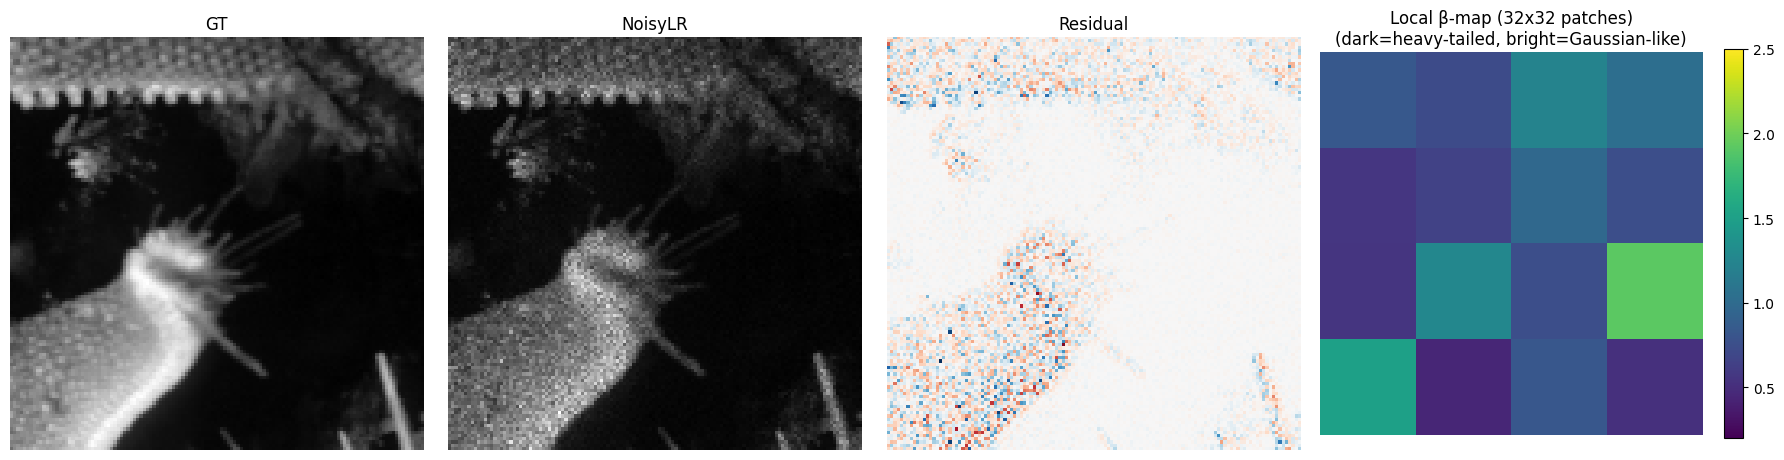

beta_map stats: min=0.446, max=1.919, mean=0.909, std=0.388


In [6]:
gt_ds, noisy_img, residual, beta_map = example_data

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
axes[0].imshow(gt_ds, cmap="gray"); axes[0].set_title("GT"); axes[0].axis("off")
axes[1].imshow(noisy_img, cmap="gray"); axes[1].set_title("NoisyLR"); axes[1].axis("off")
axes[2].imshow(residual, cmap="RdBu", vmin=-0.4, vmax=0.4); axes[2].set_title("Residual"); axes[2].axis("off")
im = axes[3].imshow(beta_map, cmap="viridis", vmin=0.2, vmax=2.5)
axes[3].set_title(f"Local β-map ({PATCH_SIZE}x{PATCH_SIZE} patches)\n(dark=heavy-tailed, bright=Gaussian-like)")
axes[3].axis("off")
plt.colorbar(im, ax=axes[3], fraction=0.046)
plt.tight_layout()
plt.show()

print(f"beta_map stats: min={np.nanmin(beta_map):.3f}, max={np.nanmax(beta_map):.3f}, "
      f"mean={np.nanmean(beta_map):.3f}, std={np.nanstd(beta_map):.3f}")

Cell 6 — Global β distribution + is spatial variation significant?

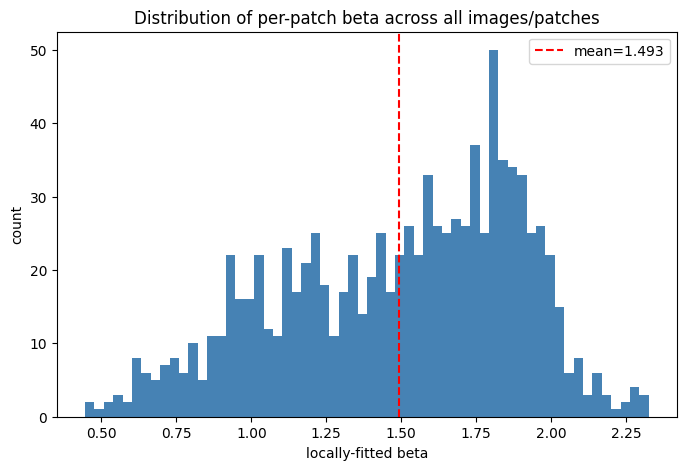

Global patch-level beta: mean=1.493, std=0.396, min=0.446, max=2.326

ANOVA across images: F=9.59, p=5.31e-62
-> Statistically significant spatial variation in beta across images/regions.


In [7]:
import pandas as pd
df = pd.DataFrame(records)

plt.figure(figsize=(8,5))
plt.hist(df["beta"], bins=60, color="steelblue")
plt.axvline(df["beta"].mean(), color="red", linestyle="--", label=f"mean={df['beta'].mean():.3f}")
plt.xlabel("locally-fitted beta"); plt.ylabel("count")
plt.title("Distribution of per-patch beta across all images/patches")
plt.legend()
plt.show()

print(f"Global patch-level beta: mean={df['beta'].mean():.3f}, std={df['beta'].std():.3f}, "
      f"min={df['beta'].min():.3f}, max={df['beta'].max():.3f}")

# One-way ANOVA across images: is between-image variance in beta larger than within-image noise?
groups = [g["beta"].values for _, g in df.groupby("image_idx") if len(g) > 1]
f_stat, p_val = stats.f_oneway(*groups)
print(f"\nANOVA across images: F={f_stat:.2f}, p={p_val:.2e}")
if p_val < 0.05:
    print("-> Statistically significant spatial variation in beta across images/regions.")
else:
    print("-> No significant spatial variation detected -- reconsider the adaptive-architecture premise.")

Cell 7 — Correlate β with structural features

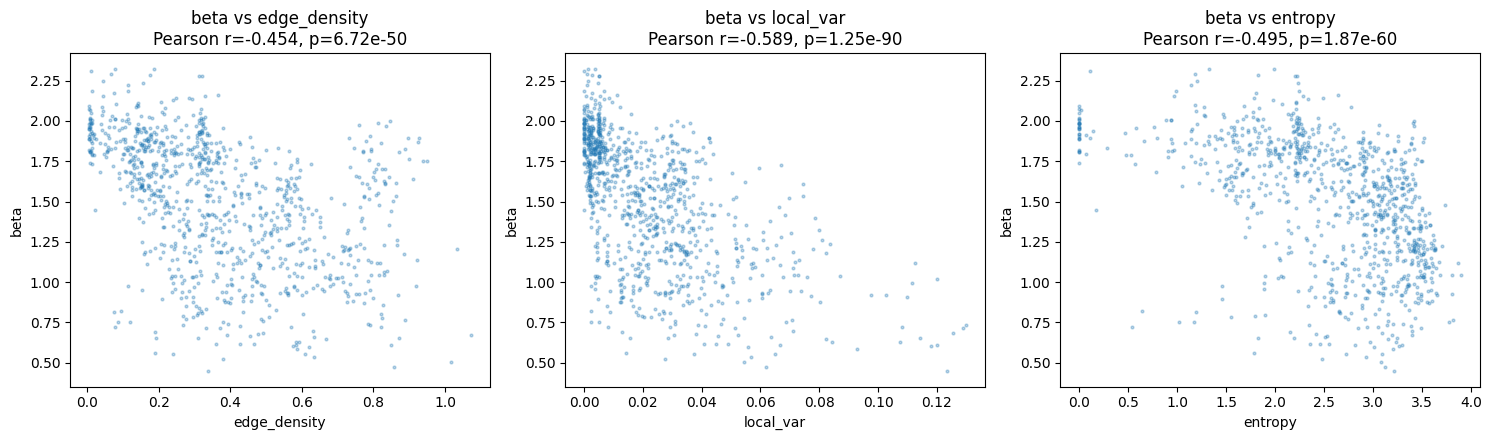

Correlation summary:
  beta vs edge_density   : r=-0.454  p=6.72e-50  (SIGNIFICANT)
  beta vs local_var      : r=-0.589  p=1.25e-90  (SIGNIFICANT)
  beta vs entropy        : r=-0.495  p=1.87e-60  (SIGNIFICANT)


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15,4.5))
feats = ["edge_density", "local_var", "entropy"]
for ax, feat in zip(axes, feats):
    r, p = stats.pearsonr(df[feat], df["beta"])
    ax.scatter(df[feat], df["beta"], s=4, alpha=0.3)
    ax.set_xlabel(feat); ax.set_ylabel("beta")
    ax.set_title(f"beta vs {feat}\nPearson r={r:.3f}, p={p:.2e}")
plt.tight_layout()
plt.show()

print("Correlation summary:")
for feat in feats:
    r, p = stats.pearsonr(df[feat], df["beta"])
    sig = "SIGNIFICANT" if p < 0.05 else "not significant"
    print(f"  beta vs {feat:15s}: r={r:+.3f}  p={p:.2e}  ({sig})")

Cell 8 — Verdict

In [9]:
print("="*70)
print("PHASE 7 VERDICT")
print("="*70)
if p_val < 0.05:
    print("Heavy-tail statistics (beta) vary significantly across spatial regions.")
    print("This justifies moving from a FIXED, uniform robust loss to an")
    print("ADAPTIVE restoration strategy that conditions on local noise character.")
    print("\nProceed to Phase 8/9: build a Noise Statistics Estimation (NSE) module")
    print("that predicts local beta (and sigma) directly from the degraded input,")
    print("supervised in part by the empirical beta-maps computed above.")
else:
    print("No significant spatial variation found -- a single global robust loss")
    print("(Gen. Charbonnier, p=0.845) may already be sufficient; adaptive")
    print("architecture would need a different justification.")

PHASE 7 VERDICT
Heavy-tail statistics (beta) vary significantly across spatial regions.
This justifies moving from a FIXED, uniform robust loss to an
ADAPTIVE restoration strategy that conditions on local noise character.

Proceed to Phase 8/9: build a Noise Statistics Estimation (NSE) module
that predicts local beta (and sigma) directly from the degraded input,
supervised in part by the empirical beta-maps computed above.


## Noise Statistics Estimation + Adaptive Routing Architecture

Cell 9 — Noise Statistics Estimation (NSE) module

In [10]:
class NoiseStatisticsEstimator(nn.Module):
    """Predicts a per-pixel (beta, sigma) map from the degraded input.
    beta in [0.2, 2.5]: <1 = heavy-tailed (e.g. dense structure), >~1.8 = near-Gaussian (background).
    sigma > 0: local noise scale.
    """
    def __init__(self, in_ch=1, base_ch=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_ch, base_ch, 3, padding=1), nn.GroupNorm(8, base_ch), nn.GELU(),
            nn.Conv2d(base_ch, base_ch, 3, padding=1), nn.GroupNorm(8, base_ch), nn.GELU(),
            nn.Conv2d(base_ch, base_ch, 3, padding=1), nn.GroupNorm(8, base_ch), nn.GELU(),
        )
        self.beta_head = nn.Conv2d(base_ch, 1, 1)
        self.sigma_head = nn.Conv2d(base_ch, 1, 1)

    def forward(self, x):
        feat = self.encoder(x)
        beta_raw = self.beta_head(feat)
        sigma_raw = self.sigma_head(feat)
        beta_map = 0.2 + 2.3 * torch.sigmoid(beta_raw)   # squash to [0.2, 2.5]
        sigma_map = F.softplus(sigma_raw) + 1e-4         # positive
        return beta_map, sigma_map, feat

Cell 10 — FiLM-style feature modulation conditioned on noise statistics

In [11]:
class NoiseConditionedFiLM(nn.Module):
    """Modulates backbone features using the predicted beta/sigma maps."""
    def __init__(self, feat_ch, cond_ch=2):
        super().__init__()
        self.to_gamma_beta = nn.Sequential(
            nn.Conv2d(cond_ch, feat_ch, 3, padding=1), nn.GELU(),
            nn.Conv2d(feat_ch, feat_ch * 2, 3, padding=1),
        )

    def forward(self, feat, beta_map, sigma_map):
        cond = torch.cat([beta_map, sigma_map], dim=1)
        gamma, shift = self.to_gamma_beta(cond).chunk(2, dim=1)
        return feat * (1 + gamma) + shift

Cell 11 — Mixture-of-Experts restoration block, routed by local β

In [12]:
class RestorationExpert(nn.Module):
    """One expert: a small residual conv block, specialized (by training) for one noise regime."""
    def __init__(self, ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1), nn.GroupNorm(8, ch), nn.GELU(),
            nn.Conv2d(ch, ch, 3, padding=1),
        )
    def forward(self, x):
        return x + self.block(x)

class BetaRoutedMoE(nn.Module):
    """Routes each spatial location to a soft mixture of K experts based on the predicted beta map.
    K=3 experts intended to specialize as: near-Gaussian, moderate-heavy-tail, strong-heavy-tail."""
    def __init__(self, ch, n_experts=3):
        super().__init__()
        self.experts = nn.ModuleList([RestorationExpert(ch) for _ in range(n_experts)])
        self.router = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.GELU(),
            nn.Conv2d(16, n_experts, 1),
        )

    def forward(self, feat, beta_map):
        # router weights from beta alone (the whole point: routing follows noise statistics)
        router_logits = self.router(beta_map)
        weights = F.softmax(router_logits, dim=1)  # [B, n_experts, H, W]

        expert_outputs = torch.stack([e(feat) for e in self.experts], dim=1)  # [B, K, C, H, W]
        weights_expanded = weights.unsqueeze(2)  # [B, K, 1, H, W]
        mixed = (expert_outputs * weights_expanded).sum(dim=1)  # [B, C, H, W]
        return mixed, weights

Cell 12 — Spatially-adaptive Generalized Charbonnier loss (uses the predicted β-map)

In [13]:
def adaptive_gen_charbonnier_loss(pred, target, beta_map, eps=1e-3):
    """Per-pixel exponent = predicted local beta, instead of one global fixed p."""
    r = pred - target
    per_pixel_loss = (r**2 + eps**2) ** (beta_map.squeeze(1) / 2)
    return per_pixel_loss.mean()

def beta_supervision_loss(predicted_beta_map, target_beta_map):
    """Optional auxiliary loss: ground the NSE head's beta predictions in the empirical
    patch-level beta-maps computed in Phase 7 (upsample target to pixel resolution first)."""
    target_up = F.interpolate(target_beta_map, size=predicted_beta_map.shape[-2:], mode="nearest")
    valid = ~torch.isnan(target_up)
    if valid.sum() == 0:
        return torch.tensor(0.0, device=predicted_beta_map.device)
    return F.mse_loss(predicted_beta_map[valid], target_up[valid])

Cell 13 — Full skeleton: Distribution-Adaptive Restoration Network

In [14]:
class DistributionAdaptiveRestorationNet(nn.Module):
    """
    Image -> Noise Statistics Estimator -> beta/sigma maps
          -> Feature extraction -> FiLM modulation (conditioned on beta/sigma)
          -> Beta-routed Mixture-of-Experts
          -> Reconstruction head -> Restored image
    """
    def __init__(self, base_ch=32, n_experts=3):
        super().__init__()
        self.nse = NoiseStatisticsEstimator(in_ch=1, base_ch=base_ch)
        self.film = NoiseConditionedFiLM(feat_ch=base_ch, cond_ch=2)
        self.moe = BetaRoutedMoE(ch=base_ch, n_experts=n_experts)
        self.recon = nn.Sequential(
            nn.Conv2d(base_ch, base_ch, 3, padding=1), nn.GELU(),
            nn.Conv2d(base_ch, 1, 3, padding=1),
        )

    def forward(self, x):
        beta_map, sigma_map, feat = self.nse(x)
        feat = self.film(feat, beta_map, sigma_map)
        feat, router_weights = self.moe(feat, beta_map)
        restored = x + self.recon(feat)   # global residual connection
        return restored, beta_map, sigma_map, router_weights

Cell 14 — Demo forward pass + adaptive loss on a real pair

restored shape: torch.Size([1, 1, 128, 128])
predicted beta_map range: [0.580, 1.652]
router_weights shape: torch.Size([1, 3, 128, 128]) (per-pixel expert mixture weights)
loss_recon=0.0426  loss_beta_sup=0.2819  total=0.0708


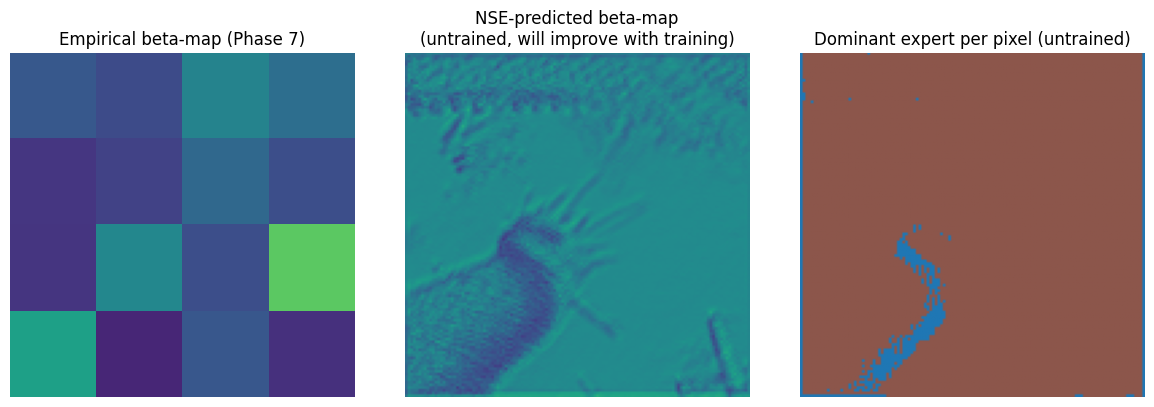

In [15]:
model = DistributionAdaptiveRestorationNet(base_ch=32, n_experts=3).to(device)

gt_ds, noisy_img, residual, empirical_beta_map = example_data
x = torch.tensor(noisy_img, dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0)
target = torch.tensor(gt_ds, dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0)
target_beta = torch.tensor(empirical_beta_map, dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0)

restored, pred_beta_map, pred_sigma_map, router_weights = model(x)

loss_recon = adaptive_gen_charbonnier_loss(restored, target, pred_beta_map)
loss_beta_sup = beta_supervision_loss(pred_beta_map, target_beta)
total_loss = loss_recon + 0.1 * loss_beta_sup

print(f"restored shape: {restored.shape}")
print(f"predicted beta_map range: [{pred_beta_map.min().item():.3f}, {pred_beta_map.max().item():.3f}]")
print(f"router_weights shape: {router_weights.shape} (per-pixel expert mixture weights)")
print(f"loss_recon={loss_recon.item():.4f}  loss_beta_sup={loss_beta_sup.item():.4f}  total={total_loss.item():.4f}")

# visualize predicted beta map vs empirical
fig, axes = plt.subplots(1, 3, figsize=(12,4))
axes[0].imshow(empirical_beta_map, cmap="viridis", vmin=0.2, vmax=2.5)
axes[0].set_title("Empirical beta-map (Phase 7)"); axes[0].axis("off")
axes[1].imshow(pred_beta_map[0,0].detach().cpu().numpy(), cmap="viridis", vmin=0.2, vmax=2.5)
axes[1].set_title("NSE-predicted beta-map\n(untrained, will improve with training)"); axes[1].axis("off")
for k in range(router_weights.shape[1]):
    pass
im = axes[2].imshow(router_weights[0].detach().cpu().numpy().argmax(0), cmap="tab10", vmin=0, vmax=2)
axes[2].set_title("Dominant expert per pixel (untrained)"); axes[2].axis("off")
plt.tight_layout()
plt.show()

Cell 15 — Toy training loop (sanity check that gradients flow correctly)

step 10: total_loss=0.0439
step 20: total_loss=0.0371
step 30: total_loss=0.0349
step 40: total_loss=0.0331
step 50: total_loss=0.0318


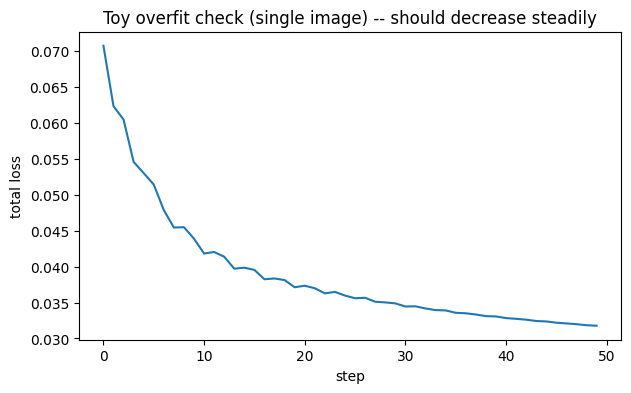

In [16]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
n_toy_steps = 50

losses = []
for step in range(n_toy_steps):
    optimizer.zero_grad()
    restored, pred_beta_map, pred_sigma_map, router_weights = model(x)
    loss_recon = adaptive_gen_charbonnier_loss(restored, target, pred_beta_map)
    loss_beta_sup = beta_supervision_loss(pred_beta_map, target_beta)
    total_loss = loss_recon + 0.1 * loss_beta_sup
    total_loss.backward()
    optimizer.step()
    losses.append(total_loss.item())
    if (step+1) % 10 == 0:
        print(f"step {step+1}: total_loss={total_loss.item():.4f}")

plt.figure(figsize=(7,4))
plt.plot(losses)
plt.xlabel("step"); plt.ylabel("total loss")
plt.title("Toy overfit check (single image) -- should decrease steadily")
plt.show()

## Local Distribution Mixture (LDM) Head (the proposed centerpiece)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LocalDistributionMixtureHead(nn.Module):
    """
    Predicts, per pixel, soft mixture weights over K learned Generalized-Gaussian
    components. Each component k has its own learnable (log_scale_k, beta_k),
    shared across the whole image/dataset -- only the assignment weight is local.
    This is the minimal, tractable version of "the global heavy tail emerges from
    mixing local distributions": we predict the mixture explicitly instead of a
    single scalar beta.
    """
    def __init__(self, in_ch=1, base_ch=32, n_components=3):
        super().__init__()
        self.K = n_components
        self.encoder = nn.Sequential(
            nn.Conv2d(in_ch, base_ch, 3, padding=1), nn.GroupNorm(8, base_ch), nn.GELU(),
            nn.Conv2d(base_ch, base_ch, 3, padding=1), nn.GroupNorm(8, base_ch), nn.GELU(),
        )
        self.weight_head = nn.Conv2d(base_ch, n_components, 1)

      
        init_betas = torch.linspace(1.8, 0.6, n_components)
        self.log_beta = nn.Parameter(torch.log(init_betas))
        self.log_scale = nn.Parameter(torch.zeros(n_components)) 

    def forward(self, x):
        feat = self.encoder(x)
        logits = self.weight_head(feat)                    # [B, K, H, W]
        mix_weights = F.softmax(logits, dim=1)              # per-pixel soft assignment
        beta = torch.exp(self.log_beta).clamp(0.2, 3.0)      # [K]
        scale = F.softplus(self.log_scale) + 1e-3            # [K]
        return mix_weights, beta, scale, feat


def mixture_gen_gaussian_nll(residual, mix_weights, beta, scale, eps=1e-6):
    """
    residual: [B,1,H,W]; mix_weights: [B,K,H,W]; beta, scale: [K]
    Generalized Gaussian log-pdf: log f(r) = log(beta / (2*scale*Gamma(1/beta)))
                                              - (|r|/scale)^beta
    Returns per-pixel mixture NLL, averaged.
    """
    K = beta.shape[0]
    r = residual.abs().unsqueeze(1)                          # [B,1,H,W] -> broadcast over K
    beta_ = beta.view(1, K, 1, 1)
    scale_ = scale.view(1, K, 1, 1)

    log_norm = torch.log(beta_) - torch.log(2 * scale_) - torch.lgamma(1.0 / beta_)
    log_comp = log_norm - (r / scale_).clamp(min=eps).pow(beta_)   # [B,K,H,W]

    log_mix = torch.logsumexp(torch.log(mix_weights + eps) + log_comp, dim=1)  # [B,H,W]
    return -log_mix.mean()

Cell — how it plugs into the restoration backbone (replaces the separate NSE + FiLM + fixed-p loss from before)

In [19]:
class DistributionMixtureRestorationNet(nn.Module):
    """
    Image -> LDMH (predicts per-pixel mixture over K noise components)
          -> mixture weights used BOTH as (a) FiLM conditioning signal
             and (b) the loss's mixture-NLL parameters
          -> lightweight backbone (drop in NAFNet/MambaIR blocks here in practice)
          -> restored image
    """
    def __init__(self, base_ch=32, n_components=3):
        super().__init__()
        self.ldmh = LocalDistributionMixtureHead(in_ch=1, base_ch=base_ch, n_components=n_components)
        self.film = nn.Sequential(
            nn.Conv2d(n_components, base_ch, 3, padding=1), nn.GELU(),
            nn.Conv2d(base_ch, base_ch * 2, 3, padding=1),
        )
        self.backbone = nn.Sequential(   # placeholder -- swap for real NAFNet/MambaIR block(s)
            nn.Conv2d(base_ch, base_ch, 3, padding=1), nn.GroupNorm(8, base_ch), nn.GELU(),
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
        )
        self.stem = nn.Conv2d(1, base_ch, 3, padding=1)
        self.head = nn.Conv2d(base_ch, 1, 3, padding=1)

    def forward(self, x):
        mix_weights, beta, scale, _ = self.ldmh(x)
        feat = self.stem(x)
        gamma, shift = self.film(mix_weights).chunk(2, dim=1)
        feat = feat * (1 + gamma) + shift
        feat = feat + self.backbone(feat)
        restored = x + self.head(feat)
        return restored, mix_weights, beta, scale